In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import zipfile
import os

with zipfile.ZipFile("student.zip", "r") as zip_ref:
    zip_ref.extractall("student_data")

print(os.listdir("student_data"))

['student-por.csv', 'student-mat.csv', 'student-merge.R', 'student.txt']


In [6]:
df = pd.read_csv("student_data/student-mat.csv", sep=";")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (395, 33)

Data Types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


In [10]:
avg_g3 = df['G3'].mean()
print(f"The average final grade (G3) is: {avg_g3:.2f}")

The average final grade (G3) is: 10.42


In [15]:
high_scorers = df[df['G3'] > 15].shape[0]
print(f"Number of students who scored above 15: {high_scorers}")

Number of students who scored above 15: 40


In [16]:
correlation = df['studytime'].corr(df['G3'])
print(f"Correlation between study time and final grade (G3): {correlation:.2f}")

Correlation between study time and final grade (G3): 0.10


In [17]:
gender_perf = df.groupby('sex')['G3'].mean()
print("Average G3 score by Gender:")
print(gender_perf)

Average G3 score by Gender:
sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


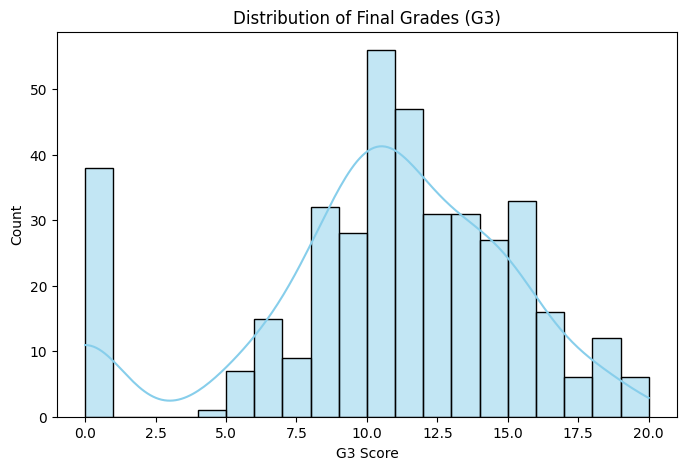

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(df['G3'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('G3 Score')
plt.ylabel('Count')
plt.show()

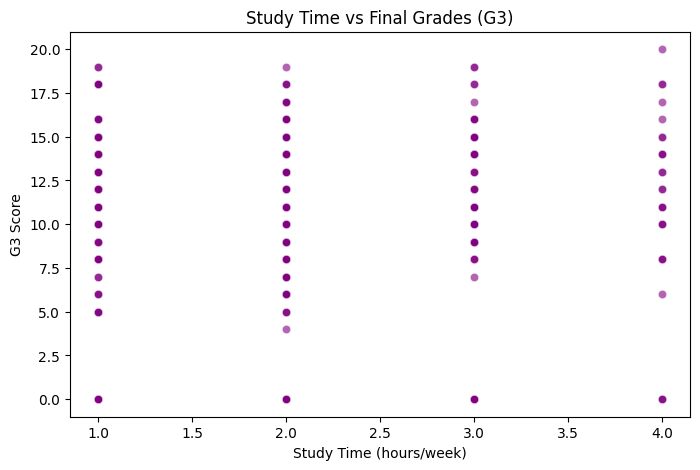

In [19]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='studytime', y='G3', data=df, alpha=0.6, color='purple')
plt.title('Study Time vs Final Grades (G3)')
plt.xlabel('Study Time (hours/week)')
plt.ylabel('G3 Score')
plt.show()

/tmp/ipykernel_1088/2902141451.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='sex', y='G3', data=df, ci=None, palette='pastel')
/tmp/ipykernel_1088/2902141451.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex', y='G3', data=df, ci=None, palette='pastel')


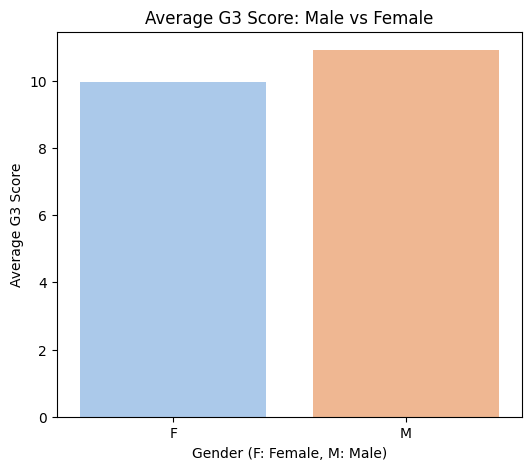

In [20]:
plt.figure(figsize=(6, 5))
sns.barplot(x='sex', y='G3', data=df, ci=None, palette='pastel')
plt.title('Average G3 Score: Male vs Female')
plt.xlabel('Gender (F: Female, M: Male)')
plt.ylabel('Average G3 Score')
plt.show()